In [1]:
import os
import sys

import seaborn as sns
from tqdm import tqdm

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 18})

# Qualitative evaluation experiments
Data drift seriously affects the test set. How is the KAN prediction distributed across the unseen feature regions?

In [2]:
# 1s
train_x, train_y = read_dataset('original')
valid_x = read_dataset(stage='original', dataset='valid')
test_x = read_dataset(stage='original', dataset='test')

train_pred = pd.read_csv('../3-fault_detection/predictions_train.csv')['faulty']
valid_pred = pd.read_csv('../3-fault_detection/predictions_valid.csv')['faulty']
test_pred = pd.read_csv('../3-fault_detection/predictions_test.csv')['faulty']

train = pd.concat([train_x, train_pred], axis='columns')
valid = pd.concat([valid_x, valid_pred], axis='columns')
test = pd.concat([test_x, test_pred], axis='columns')

## Stacked distribution of features subject to faulty state

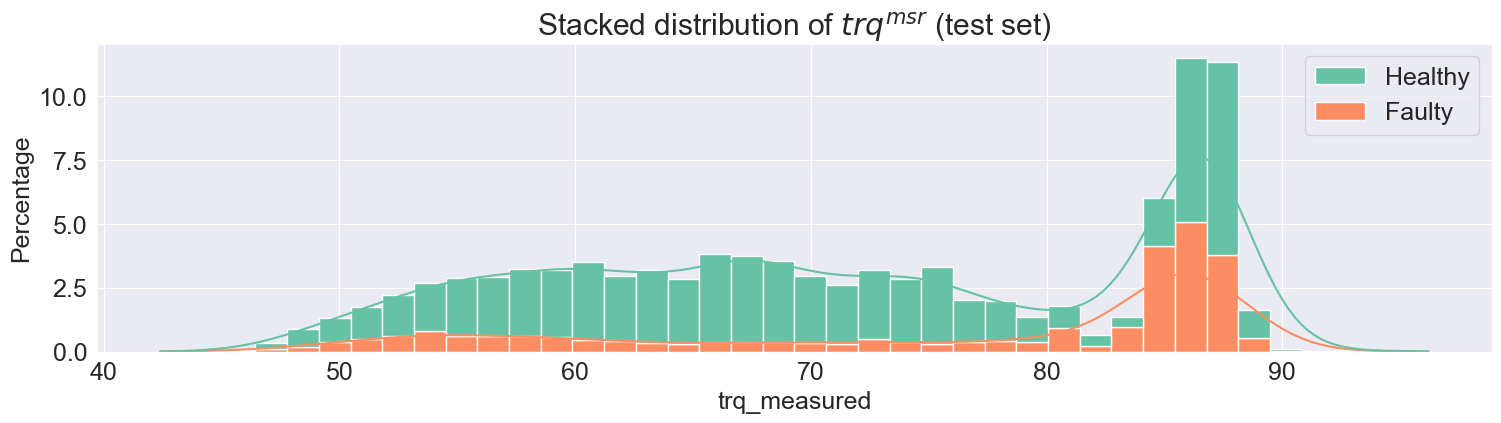

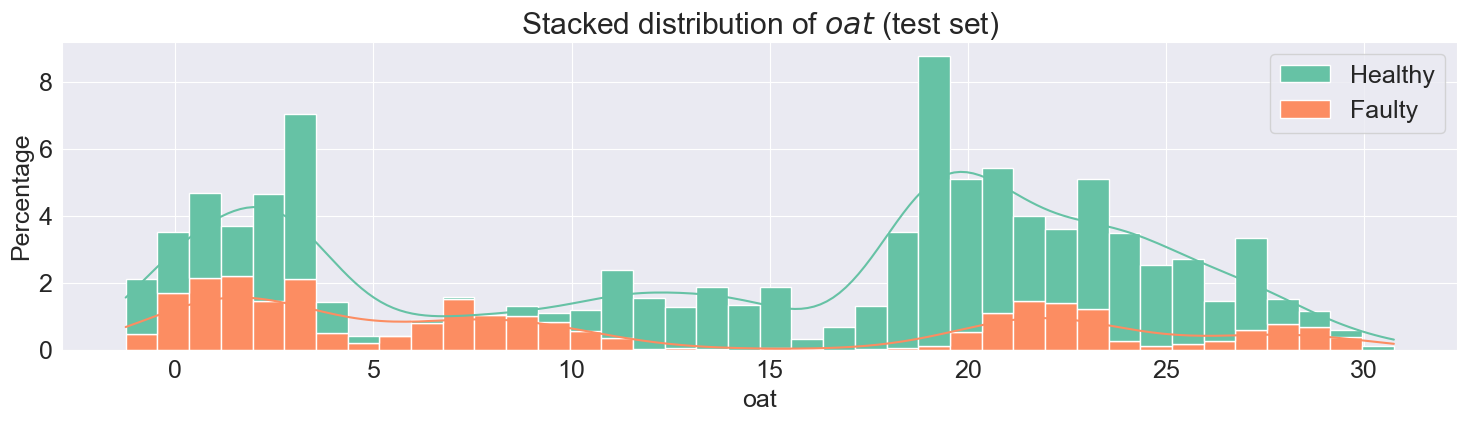

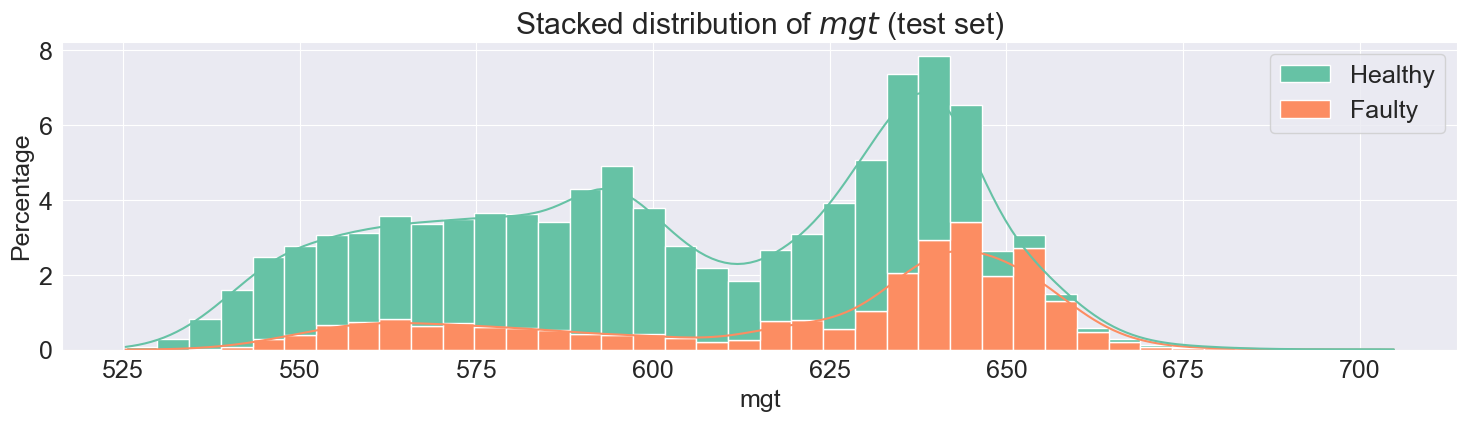

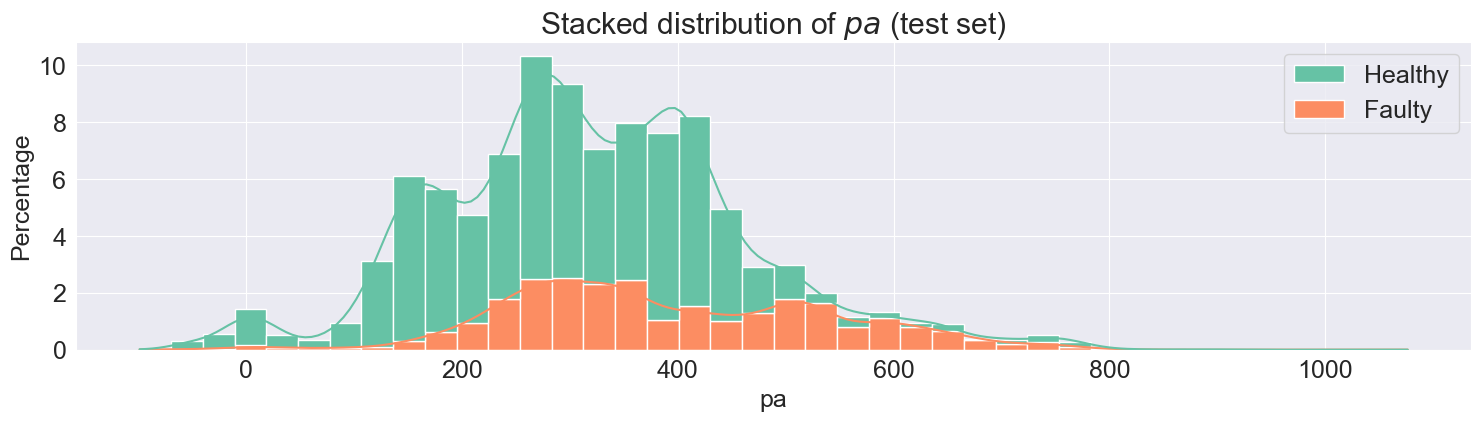

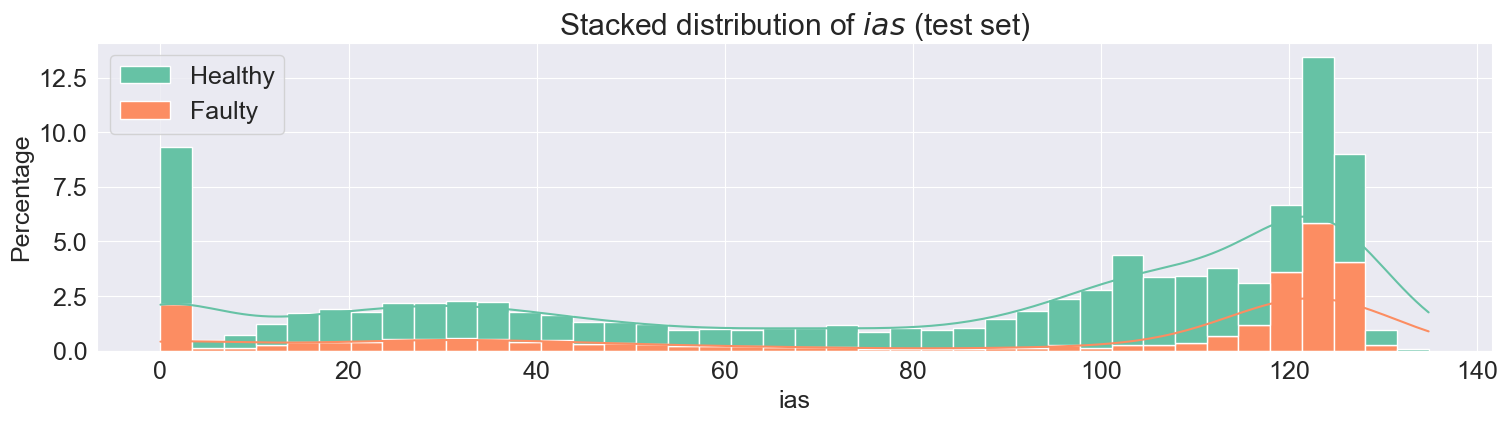

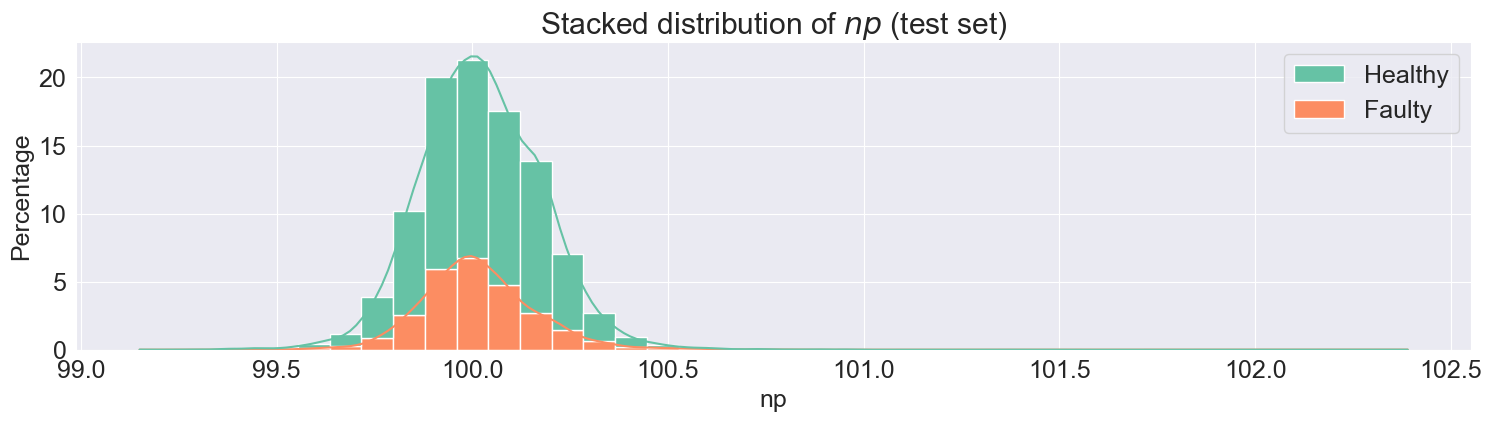

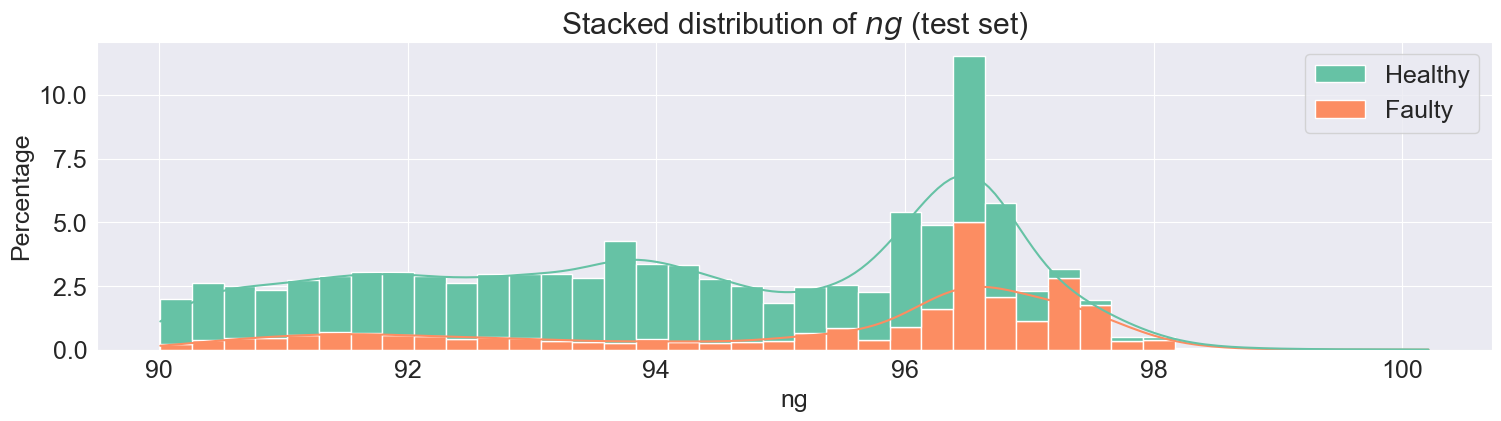

In [3]:
# 5s
for feature in train_x.columns:
    plt.figure(figsize=(18, 4))
    faulty_distribution_test = pd.DataFrame({'Healthy': test_x[test_pred < 0.5][feature],
                                             'Faulty': test_x[test_pred > 0.5][feature], })
    sns.histplot(faulty_distribution_test, multiple='stack', kde=True, alpha=1,
                 bins=40, stat='percent', palette='Set2')
    plt.title(f"Stacked distribution of {to_latex(feature)} (test set)")
    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.show()

## Difference in correlation of features with predicted faulty state between train and test sets

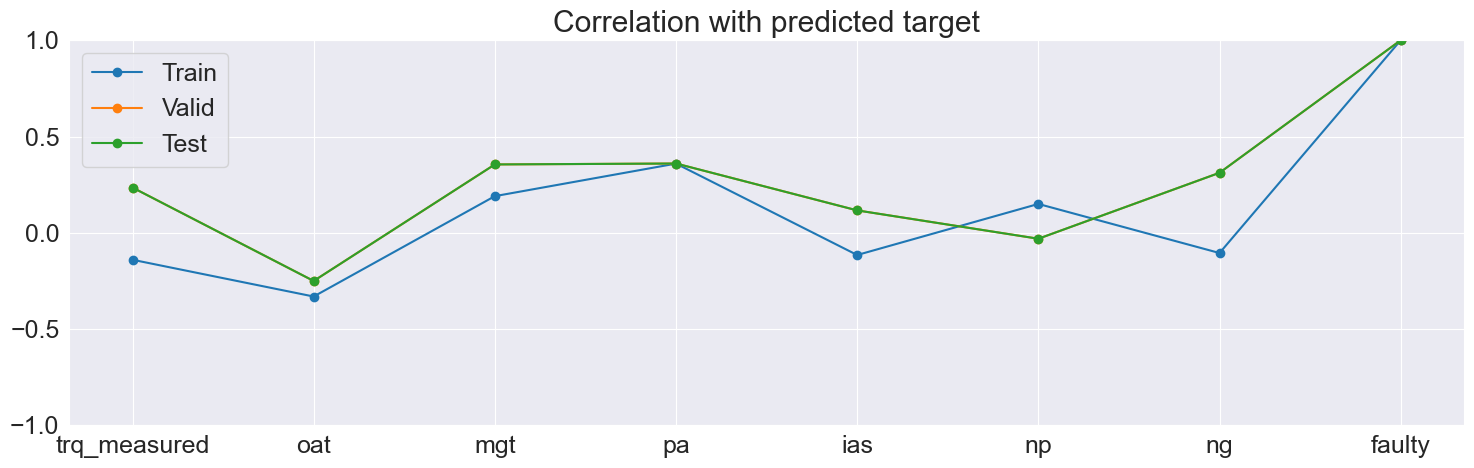

In [5]:
# 0s
plt.figure(figsize=(18, 5))
corr_train = train.corr()
corr_valid = test.corr()
corr_test = test.corr()
corr_train['faulty'].plot(label='Train', marker='o')
corr_valid['faulty'].plot(label='Valid', marker='o')
ax = corr_test['faulty'].plot(label='Test', marker='o')
ax.legend()
ax.set_ylim([-1, 1])
ax.set_title('Correlation with predicted target')
plt.show()

There are differences within the correlations, it seems that some features have more importance in the test than in the training.

100%|██████████| 7/7 [00:04<00:00,  1.41it/s]


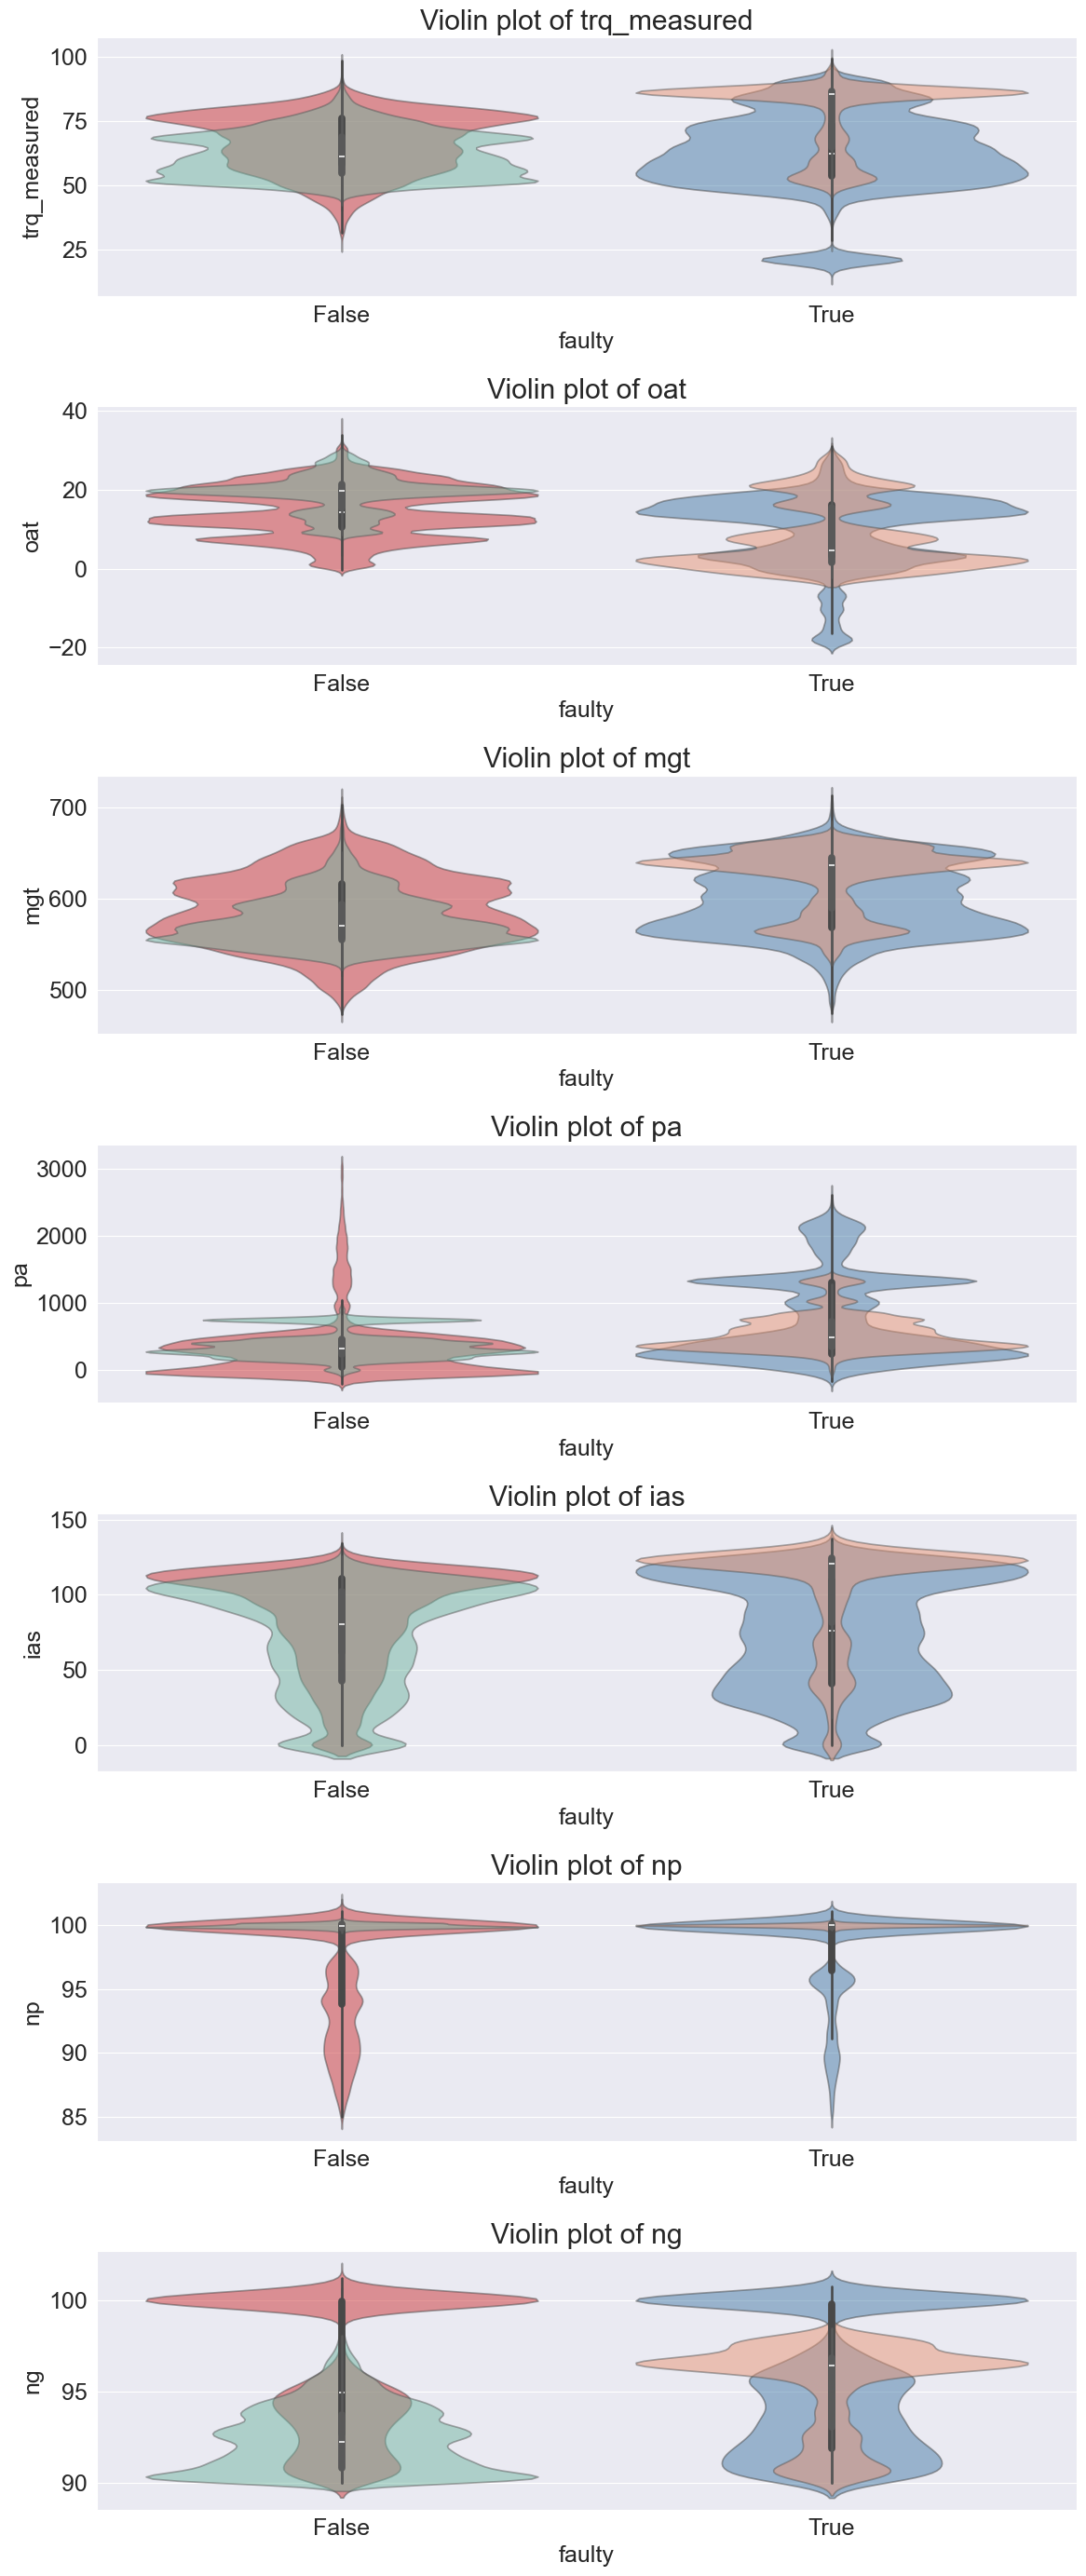

In [5]:
# 7s
fig, axes = plt.subplots(nrows=len(train_x.columns), ncols=1, figsize=(12, 4 * len(train_x.columns)))
for i, feature in enumerate(tqdm(train_x.columns)):
    ax = axes[i]
    ax.set_title(f"Violin plot of {feature}")
    for j, data in enumerate(
            [(train_x[feature][:100_000], train_pred[:100_000] > 0.5), (test_x[feature], test_pred > 0.5)]):
        sns.violinplot(
            ax=ax,
            x=data[1],
            y=data[0],
            hue=data[1],
            palette=f'Set{j + 1}',
            legend=False,
            alpha=0.5,
        )
plt.tight_layout()
plt.show()

## Outlier analysis

In [6]:
q1_train = train['trq_measured'].quantile(0.25)
q3_train = train['trq_measured'].quantile(0.75)
iqr_train = q3_train - q1_train
lower_bound_train = q1_train - 1.5 * iqr_train
upper_bound_train = q3_train + 1.5 * iqr_train
train_outliers = train[(train['trq_measured'] < lower_bound_train) | (train['trq_measured'] > upper_bound_train)]
print("N. of outlier in trq_measured (training):", len(train_outliers))
print(train_outliers[['trq_measured', 'faulty']].head())

q1_test = test['trq_measured'].quantile(0.25)
q3_test = test['trq_measured'].quantile(0.75)
iqr_test = q3_test - q1_test
lower_bound_test = q1_test - 1.5 * iqr_test
upper_bound_test = q3_test + 1.5 * iqr_test
test_outliers = test[(test['trq_measured'] < lower_bound_test) | (test['trq_measured'] > upper_bound_test)]
print("N. of outliers in trq_measured (test):", len(test_outliers))
print(test_outliers[['trq_measured', 'faulty']].head())

N. of outlier in trq_measured (training): 15621
     trq_measured    faulty
30       22.10645  0.998640
38       21.77148  0.998934
65       20.49463  0.998933
76       21.70166  0.998907
210      22.07617  0.998730
N. of outliers in trq_measured (test): 0
Empty DataFrame
Columns: [trq_measured, faulty]
Index: []


In [7]:
for col in ['oat', 'trq_measured', 'mgt', 'pa', 'ias', 'np', 'ng']:
    q_low = test[col].quantile(0.05)
    q_high = test[col].quantile(0.95)
    print(f"Range 5-95% of '{col}' on test set: {q_low} - {q_high}\n")

Range 5-95% of 'oat' on test set: 0.0 - 25.75

Range 5-95% of 'trq_measured' on test set: 50.7 - 87.3

Range 5-95% of 'mgt' on test set: 542.955 - 656.9

Range 5-95% of 'pa' on test set: 144.78 - 855.4059599999991

Range 5-95% of 'ias' on test set: 3.8468750000000114 - 125.625

Range 5-95% of 'np' on test set: 99.69 - 100.22

Range 5-95% of 'ng' on test set: 90.18 - 97.58



Non è solo trq_margin a essere fuori scala: anche mgt, np e ng risultano superiori ai valori del 95°-> il motore potrebbe trovarsi in condizioni operative anomale